# 03b. Плацебо-проверки и временное выравнивание

Сравниваются семейства сигналов по времени публикации, считается placebo на прошлую доходность и отдельно пересчитываются ключевые результаты на `clean`-подвыборке, где временной порядок между новостью и следующей торговой сессией задан однозначно

## 1. Подключение библиотек

In [1]:
import os
import re
import json
import math
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.simplefilter("default")
np.random.seed(42)

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 220)
FE_MAX_ITERS = 1000
FE_TOL = 1e-8

## 2. Пути и глобальные параметры

In [2]:
OUTPUT_DIR = "outputs_01"
MASTER_PATH = os.path.join(OUTPUT_DIR, "returns_sentiment_timing_aware.parquet")
ANALYSIS_DIR = os.path.join(OUTPUT_DIR, "analysis_03_timing_patch")
os.makedirs(ANALYSIS_DIR, exist_ok=True)

TEST_START = pd.Timestamp("2023-01-01")
ALPHA = 0.05
WINSOR_P = 0.01
APPLY_TRAIN_WINSOR = True

FE_MAX_ITERS = 500
FE_TOL = 1e-8

HORIZON_MAP = {"y1_ex": 1, "y2_ex": 2, "y3_ex": 3, "y5_ex": 5}
MAIN_MODEL = "finbert_tone"

FAMILIES_PREFERRED_ORDER = [
    "legacy",
    "clean",
    "after_close",
    "pre_open",
    "non_trading",
    "intraday",
    "unknown",
]

TEST_SORT_Q = 5

print("Путь к master-файлу:", MASTER_PATH)
print("Директория анализа:", ANALYSIS_DIR)

Путь к master-файлу: outputs_01/returns_sentiment_timing_aware.parquet
Директория анализа: outputs_01/analysis_03_timing_patch


## 3. Загрузка timing-aware master-таблицы

Проверяет наличие master-датасета, определяет доступные семейства сигналов и загружает только нужные столбцы для дальнейшего анализа

In [3]:
if not os.path.exists(MASTER_PATH):
    raise FileNotFoundError(
        f"Не найден timing-aware master-файл: {MASTER_PATH}\n"
        "Сначала запустите исправленный ноутбук 02b."
    )

all_cols = list(pd.read_parquet(MASTER_PATH, columns=None).columns)

required_base_cols = ["ticker", "date", "ret_log", "mkt_ret_log", "excess_ret_log"] + list(HORIZON_MAP.keys())
missing_base = [c for c in required_base_cols if c not in all_cols]
if missing_base:
    raise KeyError(f"В timing-aware master-файле отсутствуют обязательные столбцы: {missing_base}")

def available_families(cols: List[str], model_tag: str) -> List[str]:
    out = []
    for fam in FAMILIES_PREFERRED_ORDER:
        count_col = f"{model_tag}_{fam}_news_count"
        score_col = f"{model_tag}_{fam}_score_mean"
        if count_col in cols and score_col in cols:
            out.append(fam)
    return out

AVAILABLE_FAMILIES = available_families(all_cols, MAIN_MODEL)
if "clean" not in AVAILABLE_FAMILIES:
    raise KeyError(
        f"Для модели {MAIN_MODEL} отсутствует семейство 'clean'. Доступные семейства: {AVAILABLE_FAMILIES}"
    )

def available_clean_models(cols: List[str]) -> List[str]:
    out = []
    suffix = "_clean_score_mean"
    for c in cols:
        if c.endswith(suffix):
            out.append(c[:-len(suffix)])
    return sorted(set(out))

AVAILABLE_CLEAN_MODELS = available_clean_models(all_cols)

base_optional_cols = [c for c in ["sector"] if c in all_cols]

cols_to_load = sorted(set(
    ["ticker", "date", "ret_log", "mkt_ret_log", "excess_ret_log"] +
    base_optional_cols +
    list(HORIZON_MAP.keys()) +
    [f"{MAIN_MODEL}_{fam}_news_count" for fam in AVAILABLE_FAMILIES] +
    [f"{MAIN_MODEL}_{fam}_score_mean" for fam in AVAILABLE_FAMILIES] +
    [f"{MAIN_MODEL}_{fam}_neg_share" for fam in AVAILABLE_FAMILIES if f"{MAIN_MODEL}_{fam}_neg_share" in all_cols] +
    [f"{MAIN_MODEL}_{fam}_pos_share" for fam in AVAILABLE_FAMILIES if f"{MAIN_MODEL}_{fam}_pos_share" in all_cols] +
    [f"{m}_clean_score_mean" for m in AVAILABLE_CLEAN_MODELS] +
    [f"{m}_clean_neg_share" for m in AVAILABLE_CLEAN_MODELS if f"{m}_clean_neg_share" in all_cols] +
    [f"{m}_clean_pos_share" for m in AVAILABLE_CLEAN_MODELS if f"{m}_clean_pos_share" in all_cols] +
    [f"{m}_clean_news_count" for m in AVAILABLE_CLEAN_MODELS if f"{m}_clean_news_count" in all_cols]
))

df = pd.read_parquet(MASTER_PATH, columns=cols_to_load)
df["ticker"] = df["ticker"].astype(str).str.strip()
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
df = df.dropna(subset=["ticker", "date"]).copy()
df = df.sort_values(["ticker", "date"], kind="mergesort").reset_index(drop=True)

for y_col, h in HORIZON_MAP.items():
    df[f"date_plus_{h}"] = df.groupby("ticker", sort=False)["date"].shift(-h)

df["lag1_excess_ret"] = df.groupby("ticker", sort=False)["excess_ret_log"].shift(1)

print("Число строк:", f"{len(df):,}")
print("Число тикеров:", int(df['ticker'].nunique()))
print("Период:", df["date"].min().date(), "—", df["date"].max().date())
print("Доступные семейства сигналов:", AVAILABLE_FAMILIES)
print("Доступные clean-модели:", AVAILABLE_CLEAN_MODELS)

Число строк: 2,580,236
Число тикеров: 2054
Период: 2019-01-02 — 2023-12-28
Доступные семейства сигналов: ['legacy', 'clean', 'after_close', 'pre_open', 'non_trading', 'intraday', 'unknown']
Доступные clean-модели: ['finbert_tone']


## 4. Быстрый аудит покрытия

Считается базовая статистика по панели и строится график покрытия для разных семейств сигналов. Это помогает понять, насколько широко представлены `clean`, `legacy`, `intraday` и другие варианты

,metric,value
0,n_rows,2580236
1,n_tickers,2054
2,min_date,2019-01-02
3,max_date,2023-12-28
4,share_days_with_legacy,0.207185
5,mean_news_count_legacy,0.476786
6,share_days_with_clean,0.004435
7,mean_news_count_clean,0.008543
8,share_days_with_after_close,0.000887
9,mean_news_count_after_close,0.001522


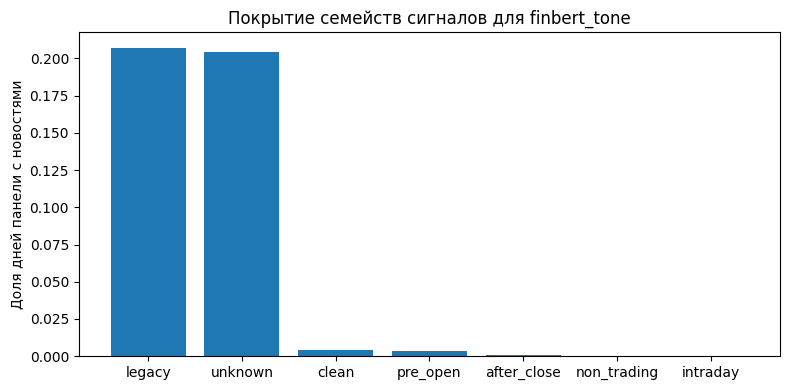

In [4]:
audit_rows = [
    {"metric": "n_rows", "value": int(len(df))},
    {"metric": "n_tickers", "value": int(df["ticker"].nunique())},
    {"metric": "min_date", "value": str(df["date"].min().date())},
    {"metric": "max_date", "value": str(df["date"].max().date())},
]

for fam in AVAILABLE_FAMILIES:
    c = f"{MAIN_MODEL}_{fam}_news_count"
    audit_rows.append({
        "metric": f"share_days_with_{fam}",
        "value": float(pd.to_numeric(df[c], errors="coerce").fillna(0).gt(0).mean()),
    })
    audit_rows.append({
        "metric": f"mean_news_count_{fam}",
        "value": float(pd.to_numeric(df[c], errors="coerce").fillna(0).mean()),
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

family_bar = []
for fam in AVAILABLE_FAMILIES:
    c = f"{MAIN_MODEL}_{fam}_news_count"
    family_bar.append({"family": fam, "share_days": float(pd.to_numeric(df[c], errors="coerce").fillna(0).gt(0).mean())})

family_bar = pd.DataFrame(family_bar).sort_values("share_days", ascending=False)
plt.figure(figsize=(8, 4))
plt.bar(family_bar["family"], family_bar["share_days"])
plt.ylabel("Доля дней панели с новостями")
plt.title(f"Покрытие семейств сигналов для {MAIN_MODEL}")
plt.tight_layout()
plt.show()

## 5. Вспомогательные функции

Функции для очистки выборки, стандартизации, винсоризации, двухсторонних фиксированных эффектов, кластерных стандартных ошибок, FDR-коррекции и тестовых сортировок

In [5]:
def bh_fdr(pvals) -> np.ndarray:
    s = pd.to_numeric(pd.Series(pvals), errors="coerce").astype(float).values
    n = len(s)
    out = np.full(n, np.nan, dtype=float)

    ok = np.isfinite(s)
    if ok.sum() == 0:
        return out

    pv = s[ok]
    order = np.argsort(pv)
    ranked = pv[order]
    q = ranked * len(ranked) / (np.arange(len(ranked)) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)

    loc = np.where(ok)[0][order]
    out[loc] = q
    return out

def require_columns(df_in: pd.DataFrame, cols: List[str], context: str):
    miss = [c for c in cols if c not in df_in.columns]
    if miss:
        raise KeyError(f"[{context}] отсутствуют столбцы: {miss}")

def winsor_bounds(s: pd.Series, p: float = 0.01) -> Tuple[float, float]:
    x = pd.to_numeric(s, errors="coerce").dropna().astype(float)
    if x.empty:
        return np.nan, np.nan
    return float(x.quantile(p)), float(x.quantile(1 - p))

def apply_bounds(s: pd.Series, lo: float, hi: float) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce").astype(float)
    if np.isfinite(lo):
        x = x.clip(lower=lo)
    if np.isfinite(hi):
        x = x.clip(upper=hi)
    return x

def standardize_on_train(train_s: pd.Series, target_s: pd.Series) -> Tuple[pd.Series, float, float]:
    tr = pd.to_numeric(train_s, errors="coerce").astype(float)
    x = pd.to_numeric(target_s, errors="coerce").astype(float)
    mu = float(tr.mean()) if tr.notna().any() else np.nan
    sd = float(tr.std(ddof=0)) if tr.notna().any() else np.nan
    if np.isfinite(sd) and sd > 0:
        z = (x - mu) / sd
    else:
        z = pd.Series(np.nan, index=x.index, dtype=float)
    return z, mu, sd

def clean_required(df_in: pd.DataFrame, required_cols: List[str], numeric_cols: List[str]) -> pd.DataFrame:
    require_columns(df_in, required_cols, "clean_required")
    z = df_in.copy()
    for c in numeric_cols:
        z[c] = pd.to_numeric(z[c], errors="coerce")
    z = z.replace([np.inf, -np.inf], np.nan)
    return z.dropna(subset=required_cols).copy()

def select_family_sample(df_in: pd.DataFrame, family: str, model: str = MAIN_MODEL) -> pd.DataFrame:
    count_col = f"{model}_{family}_news_count"
    score_col = f"{model}_{family}_score_mean"
    require_columns(df_in, [count_col, score_col], f"select_family_sample[{family}]")
    out = df_in.copy()
    cnt = pd.to_numeric(out[count_col], errors="coerce").fillna(0)
    out = out[cnt.gt(0)].copy()
    return out

def horizon_safe_split(df_in: pd.DataFrame, y_col: str, test_start: pd.Timestamp) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if y_col not in HORIZON_MAP:
        raise KeyError(f"Неизвестная колонка горизонта: {y_col}")
    future_col = f"date_plus_{HORIZON_MAP[y_col]}"
    require_columns(df_in, ["date", future_col], "horizon_safe_split")
    train = df_in[(df_in["date"] < test_start) & (df_in[future_col] < test_start)].copy()
    test = df_in[(df_in["date"] >= test_start) & (df_in[future_col].notna())].copy()
    return train, test

def within_transform(
    df_in: pd.DataFrame,
    cols: List[str],
    fe_cols: Optional[List[str]] = None,
    max_iter: int = FE_MAX_ITERS,
    tol: float = FE_TOL,
    return_info: bool = False,
):
    require_columns(df_in, list(cols) + list(fe_cols or []), "within_transform")
    work = df_in[cols].apply(pd.to_numeric, errors="coerce").astype(float).copy()
    info = {"fe_cols": list(fe_cols or []), "n_iter": 0, "converged": True, "max_abs_change": 0.0}

    if not fe_cols:
        return (work, info) if return_info else work

    if len(fe_cols) == 1:
        fe = fe_cols[0]
        out = work - work.groupby(df_in[fe], sort=False)[cols].transform("mean")
        info["n_iter"] = 1
        return (out, info) if return_info else out

    converged = False
    last_diff = np.inf

    for it in range(1, max_iter + 1):
        prev = work.to_numpy(copy=True)
        for fe in fe_cols:
            work = work - work.groupby(df_in[fe], sort=False)[cols].transform("mean")

        diff = np.nanmax(np.abs(work.to_numpy(copy=False) - prev))
        if not np.isfinite(diff):
            raise FloatingPointError("within_transform получил нечисловую метрику сходимости.")

        last_diff = float(diff)

        if diff < tol:
            info["n_iter"] = it
            info["converged"] = True
            info["max_abs_change"] = float(diff)
            converged = True
            break

    if not converged:


        relaxed_tol = max(float(tol) * 1000.0, 1e-5)

        if np.isfinite(last_diff) and last_diff <= relaxed_tol:
            info["n_iter"] = max_iter
            info["converged"] = True
            info["max_abs_change"] = float(last_diff)
            warnings.warn(
                f"within_transform остановился на max_iter={max_iter} с последним отклонением = {last_diff:.3e}; "
                f"принимается как численно сошедшийся при relaxed_tol = {relaxed_tol:.3e}.",
                RuntimeWarning,
            )
            converged = True
        else:
            raise RuntimeError(
                f"within_transform не сошёлся за {max_iter} итераций; последнее отклонение = {last_diff:.3e}"
            )

    return (work, info) if return_info else work

def fit_clustered_model(
    df_in: pd.DataFrame,
    y: str,
    x_cols: List[str],
    fe_cols: Optional[List[str]] = None,
    cluster_cols: Optional[List[str]] = None,
    add_const: bool = False,
):
    from statsmodels.stats.sandwich_covariance import cov_cluster, cov_cluster_2groups

    cluster_cols = cluster_cols or ["ticker", "date"]
    required = list(dict.fromkeys([y] + list(x_cols) + list(cluster_cols) + list(fe_cols or [])))
    num_cols = [c for c in required if c not in set(cluster_cols + (fe_cols or []))]
    z = clean_required(df_in, required, num_cols)
    if z.empty:
        return None, z, []

    transformed, fe_info = within_transform(z, [y] + list(x_cols), fe_cols=fe_cols, return_info=True)
    yv = transformed[y].astype(float)
    X = transformed[x_cols].astype(float)

    keep_x = [c for c in X.columns if float(np.nanstd(X[c].values)) > 1e-14]
    X = X[keep_x]
    if X.empty:
        return None, z, keep_x

    if add_const:
        X = sm.add_constant(X, has_constant="add")

    base = sm.OLS(yv.values, X).fit()

    if len(cluster_cols) == 1:
        g = pd.factorize(z[cluster_cols[0]])[0].astype(np.int64, copy=False)
        cov = cov_cluster(base, g)
    elif len(cluster_cols) == 2:
        g1 = pd.factorize(z[cluster_cols[0]])[0].astype(np.int64, copy=False)
        g2 = pd.factorize(z[cluster_cols[1]])[0].astype(np.int64, copy=False)
        cov, _, _ = cov_cluster_2groups(base, g1, g2)
    else:
        raise ValueError("Поддерживается только одно- или двумерная кластеризация.")

    base.cov_params_default = cov
    for attr in ["_bse", "_tvalues", "_pvalues", "_cov_params"]:
        if hasattr(base, attr):
            try:
                delattr(base, attr)
            except Exception:
                pass

    base._fe_info = fe_info
    base._kept_x = keep_x
    return base, z, keep_x

def model_params_cov(model) -> Tuple[pd.Series, pd.DataFrame]:
    names = list(model.model.exog_names)
    params = pd.Series(np.asarray(model.params), index=names, dtype=float)
    cov = pd.DataFrame(np.asarray(model.cov_params()), index=names, columns=names, dtype=float)
    return params, cov

def coef_stats(model, var: str) -> Dict[str, float]:
    from scipy.stats import t as student_t

    params, cov = model_params_cov(model)
    beta = float(params.get(var, np.nan))
    if var in cov.index and np.isfinite(cov.loc[var, var]) and cov.loc[var, var] >= 0:
        se = float(math.sqrt(cov.loc[var, var]))
    else:
        se = np.nan
    tval = beta / se if np.isfinite(se) and se > 0 else np.nan
    p_two = float(2 * student_t.sf(abs(tval), float(model.df_resid))) if np.isfinite(tval) and model.df_resid > 0 else np.nan
    return {"beta": beta, "se": se, "t": tval, "p_two": p_two}

def linear_combo(model, weights: Dict[str, float]) -> Dict[str, float]:
    from scipy.stats import t as student_t

    params, cov = model_params_cov(model)
    vec = pd.Series(0.0, index=params.index)
    for name, w in weights.items():
        if name in vec.index:
            vec.loc[name] = float(w)

    beta = float((vec * params).sum())
    var = float(vec.values @ cov.values @ vec.values)
    se = math.sqrt(var) if np.isfinite(var) and var >= 0 else np.nan
    tval = beta / se if np.isfinite(se) and se > 0 else np.nan
    p_two = float(2 * student_t.sf(abs(tval), float(model.df_resid))) if np.isfinite(tval) and model.df_resid > 0 else np.nan
    return {"beta": beta, "se": se, "t": tval, "p_two": p_two}

def wald_joint_zero(model, cols: List[str]) -> Tuple[float, float]:
    from scipy.stats import chi2

    params, cov = model_params_cov(model)
    cols = [c for c in cols if c in params.index]
    if not cols:
        return np.nan, np.nan

    b = params.reindex(cols).fillna(0.0).values.astype(float)
    V = cov.reindex(index=cols, columns=cols).fillna(0.0).values.astype(float)

    try:
        Vinv = np.linalg.pinv(V)
        stat = float(b.T @ Vinv @ b)
        p = float(chi2.sf(stat, len(cols)))
    except Exception:
        stat = np.nan
        p = np.nan
    return stat, p

def apply_train_winsor_pair(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    col: str,
    p: float = WINSOR_P,
) -> Tuple[pd.DataFrame, pd.DataFrame, Tuple[float, float]]:
    lo, hi = winsor_bounds(train_df[col], p=p)
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df[col] = apply_bounds(train_df[col], lo, hi)
    test_df[col] = apply_bounds(test_df[col], lo, hi)
    return train_df, test_df, (lo, hi)

def assign_quantile_by_date(s: pd.Series, q: int = 5) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    if x.notna().sum() < q:
        return pd.Series(np.nan, index=s.index, dtype=object)
    r = x.rank(method="first")
    try:
        out = pd.Series(pd.qcut(r, q=q, labels=[str(i) for i in range(1, q + 1)]), index=s.index, dtype=object)
        out[pd.isna(out)] = np.nan
        return out
    except Exception:
        return pd.Series(np.nan, index=s.index, dtype=object)

def display_or_note(df_in: pd.DataFrame, note: str = "Пустая таблица") -> None:
    if isinstance(df_in, pd.DataFrame) and df_in.empty:
        from IPython.display import HTML, display
        display(HTML(f"<div><em>{note}</em></div>"))
    else:
        display(df_in)

## 6. Сравнение семейств сигналов: основной эффект и placebo

Для каждого семейства оцениваются основной коэффициент на следующую доходность и placebo на прошлую доходность. Этот блок нужен, чтобы показать, где временное загрязнение сильнее всего

In [6]:
def prepare_family_pair(
    df_in: pd.DataFrame,
    family: str,
    y_col: str,
    model: str = MAIN_MODEL,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict]:
    score_col = f"{model}_{family}_score_mean"
    sample = select_family_sample(df_in, family=family, model=model)
    if y_col in HORIZON_MAP:
        train, test = horizon_safe_split(sample, y_col, TEST_START)
    else:
        train = sample[sample["date"] < TEST_START].copy()
        test = sample[sample["date"] >= TEST_START].copy()

    tr = clean_required(train, ["ticker", "date", y_col, score_col], [y_col, score_col])
    te = clean_required(test, ["ticker", "date", y_col, score_col], [y_col, score_col])

    bounds = (np.nan, np.nan)
    if APPLY_TRAIN_WINSOR:
        tr, te, bounds = apply_train_winsor_pair(tr, te, y_col, p=WINSOR_P)

    tr["sent_z"], mu, sd = standardize_on_train(tr[score_col], tr[score_col])
    if np.isfinite(sd) and sd > 0:
        te["sent_z"] = (pd.to_numeric(te[score_col], errors="coerce") - mu) / sd
    else:
        te["sent_z"] = np.nan

    tr = tr.dropna(subset=["sent_z"]).copy()
    te = te.dropna(subset=["sent_z"]).copy()

    meta = {
        "score_col": score_col,
        "n_train": int(len(tr)),
        "n_test": int(len(te)),
        "winsor_lo": bounds[0],
        "winsor_hi": bounds[1],
    }
    return tr, te, meta

def estimate_twfe_single_x(df_in: pd.DataFrame, y_col: str, x_col: str = "sent_z"):
    model, used, kept = fit_clustered_model(
        df_in,
        y=y_col,
        x_cols=[x_col],
        fe_cols=["ticker", "date"],
        cluster_cols=["ticker", "date"],
        add_const=False,
    )
    return model

def run_family_comparison(df_in: pd.DataFrame, families: List[str]) -> pd.DataFrame:
    rows = []
    for fam in families:
        tr_main, te_main, meta_main = prepare_family_pair(df_in, fam, "y1_ex", model=MAIN_MODEL)
        if tr_main.empty:
            continue
        mod_main = estimate_twfe_single_x(tr_main, y_col="y1_ex", x_col="sent_z")
        st_main = coef_stats(mod_main, "sent_z") if mod_main is not None else {"beta": np.nan, "se": np.nan, "t": np.nan, "p_two": np.nan}

        tr_pl, _, meta_pl = prepare_family_pair(df_in, fam, "lag1_excess_ret", model=MAIN_MODEL)
        mod_pl = estimate_twfe_single_x(tr_pl, y_col="lag1_excess_ret", x_col="sent_z") if not tr_pl.empty else None
        st_pl = coef_stats(mod_pl, "sent_z") if mod_pl is not None else {"beta": np.nan, "se": np.nan, "t": np.nan, "p_two": np.nan}

        q1_spread = np.nan
        q1_p = np.nan
        if not te_main.empty:
            z = te_main[["date", "ticker", "y1_ex", "sent_z"]].copy()
            z["bucket"] = (
                z.groupby("date", sort=False)["sent_z"]
                 .apply(assign_quantile_by_date, q=TEST_SORT_Q)
                 .reset_index(level=0, drop=True)
            )
            z = z.dropna(subset=["bucket"]).copy()
            if not z.empty:
                daily = z.groupby(["date", "bucket"])["y1_ex"].mean().unstack("bucket")
                if "1" in daily.columns and str(TEST_SORT_Q) in daily.columns:
                    spread = daily[str(TEST_SORT_Q)] - daily["1"]
                    n = int(spread.notna().sum())
                    if n > 1:
                        q1_spread = float(spread.mean())
                        q1_se = float(spread.std(ddof=1) / np.sqrt(n))
                        q1_t = q1_spread / q1_se if np.isfinite(q1_se) and q1_se > 0 else np.nan
                        from scipy.stats import t as student_t
                        q1_p = float(2 * student_t.sf(abs(q1_t), max(n - 1, 1))) if np.isfinite(q1_t) else np.nan

        ratio = np.nan
        if np.isfinite(st_main["beta"]) and abs(st_main["beta"]) > 0 and np.isfinite(st_pl["beta"]):
            ratio = abs(st_pl["beta"]) / abs(st_main["beta"])

        rows.append({
            "family": fam,
            "main_beta_1sd": st_main["beta"],
            "main_se_1sd": st_main["se"],
            "main_t": st_main["t"],
            "main_p_two_sided": st_main["p_two"],
            "placebo_beta_1sd": st_pl["beta"],
            "placebo_se_1sd": st_pl["se"],
            "placebo_t": st_pl["t"],
            "placebo_p_two_sided": st_pl["p_two"],
            "abs_placebo_over_abs_main": ratio,
            "test_spread_q_last_minus_q1_bps": 10000 * q1_spread if np.isfinite(q1_spread) else np.nan,
            "test_spread_p_two_sided": q1_p,
            "n_train_main": meta_main["n_train"],
            "n_test_main": meta_main["n_test"],
            "n_train_placebo": meta_pl["n_train"],
        })
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["main_beta_bps"] = 10000 * out["main_beta_1sd"]
    out["placebo_beta_bps"] = 10000 * out["placebo_beta_1sd"]
    fam_order = {fam: i for i, fam in enumerate(FAMILIES_PREFERRED_ORDER)}
    out["_fam_ord"] = out["family"].map(fam_order).fillna(9999)
    out = out.sort_values(["_fam_ord", "family"]).drop(columns="_fam_ord").reset_index(drop=True)
    return out

family_cmp = run_family_comparison(df, AVAILABLE_FAMILIES)
display(family_cmp)

family_cmp_path = os.path.join(ANALYSIS_DIR, "timing_family_comparison.csv")
family_cmp.to_csv(family_cmp_path, index=False)
print("Сохранено:", family_cmp_path)

,family,main_beta_1sd,main_se_1sd,main_t,main_p_two_sided,placebo_beta_1sd,placebo_se_1sd,placebo_t,placebo_p_two_sided,abs_placebo_over_abs_main,test_spread_q_last_minus_q1_bps,test_spread_p_two_sided,n_train_main,n_test_main,n_train_placebo,main_beta_bps,placebo_beta_bps
0,legacy,0.000529,0.000046,11.506702,1.233667e-30,0.001233,0.000047,26.063225,1.257939e-149,2.331585,10.360687,0.000074,416657,117655,415853,5.286732,12.326464
1,clean,0.013425,0.000565,23.746809,1.296108e-121,-0.000752,0.000445,-1.691151,9.083616e-02,0.056017,NaN,NaN,11029,414,11029,134.253017,-7.520495
2,after_close,0.013895,0.001606,8.653053,9.587763e-18,0.004283,0.001493,2.868631,4.162373e-03,0.308237,NaN,NaN,2171,117,2171,138.949834,42.829502
3,pre_open,0.012063,0.000626,19.271274,3.614210e-81,-0.001214,0.000456,-2.659261,7.844738e-03,0.100608,NaN,NaN,9243,0,9243,120.630794,-12.136456
4,non_trading,0.010596,0.002647,4.002714,6.962282e-05,-0.004061,0.001898,-2.139490,3.275722e-02,0.383252,NaN,NaN,670,366,670,105.960250,-40.609444
5,intraday,0.061683,0.000832,74.181782,1.943673e-106,-0.015267,0.001468,-10.398486,1.065730e-18,0.247510,NaN,NaN,128,0,128,616.833333,-152.672602
6,unknown,0.000471,0.000046,10.317997,5.884248e-25,0.001228,0.000047,26.341748,8.569862e-153,2.610289,10.349453,0.000071,409619,117429,408819,4.705270,12.282112


Сохранено: outputs_01/analysis_03_timing_patch/timing_family_comparison.csv


### Визуализация сравнения семейств

Сравнивает основной эффект и placebo между разными семействами сигналов

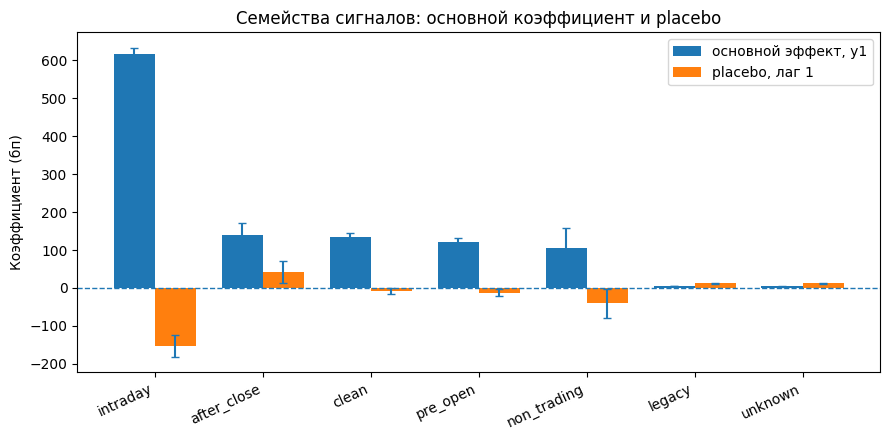

In [7]:
if not family_cmp.empty:
    tmp = family_cmp.copy().sort_values("main_beta_bps", ascending=False)

    plt.figure(figsize=(9, 4.5))
    x = np.arange(len(tmp))
    w = 0.38
    plt.bar(x - w / 2, tmp["main_beta_bps"].values, width=w, label="основной эффект, y1")
    plt.bar(x + w / 2, tmp["placebo_beta_bps"].values, width=w, label="placebo, лаг 1")
    plt.errorbar(x - w / 2, tmp["main_beta_bps"].values, yerr=1.96 * tmp["main_se_1sd"].values * 10000, fmt="none", capsize=3)
    plt.errorbar(x + w / 2, tmp["placebo_beta_bps"].values, yerr=1.96 * tmp["placebo_se_1sd"].values * 10000, fmt="none", capsize=3)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(x, tmp["family"], rotation=25, ha="right")
    plt.ylabel("Коэффициент (бп)")
    plt.title("Семейства сигналов: основной коэффициент и placebo")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. H1 на clean-подвыборке

Пересчитывается основной результат на `clean`-сигнале: оценивается лестница спецификаций и формируются вневыборочные квинтильные сортировки

In [8]:
def run_h1_clean_spec_ladder(df_in: pd.DataFrame) -> pd.DataFrame:
    rows = []
    spec_map = {
        "pooled_clustered": {"fe_cols": None, "add_const": True},
        "firm_fe": {"fe_cols": ["ticker"], "add_const": False},
        "two_way_fe": {"fe_cols": ["ticker", "date"], "add_const": False},
    }

    for y_col in ["y1_ex", "y2_ex", "y3_ex", "y5_ex"]:
        tr, te, meta = prepare_family_pair(df_in, "clean", y_col, model=MAIN_MODEL)
        if tr.empty:
            continue

        work = tr[["ticker", "date", y_col, "sent_z"]].copy()
        if "mkt_ret_log" in df_in.columns:
            work = work.merge(
                df_in[["ticker", "date", "mkt_ret_log"]],
                on=["ticker", "date"],
                how="left",
                validate="one_to_one",
            )

        for spec_name, spec_cfg in spec_map.items():
            x_cols = ["sent_z"]
            if spec_name != "two_way_fe" and "mkt_ret_log" in work.columns:
                x_cols = ["sent_z", "mkt_ret_log"]

            model, used, kept = fit_clustered_model(
                work,
                y=y_col,
                x_cols=x_cols,
                fe_cols=spec_cfg["fe_cols"],
                cluster_cols=["ticker", "date"],
                add_const=spec_cfg["add_const"],
            )
            if model is None:
                continue

            st = coef_stats(model, "sent_z")
            rows.append({
                "horizon": y_col,
                "h_days": HORIZON_MAP[y_col],
                "spec": spec_name,
                "beta_1sd": st["beta"],
                "se_1sd": st["se"],
                "t": st["t"],
                "p_two_sided": st["p_two"],
                "effect_1sd_bps": 10000 * st["beta"],
                "n_train_used": int(model.nobs),
            })

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(["spec", "h_days"]).reset_index(drop=True)

def run_h1_clean_test_sorts(df_in: pd.DataFrame, q: int = TEST_SORT_Q) -> Tuple[pd.DataFrame, pd.DataFrame]:
    sort_rows = []
    spread_rows = []

    for y_col in ["y1_ex", "y2_ex", "y3_ex", "y5_ex"]:
        tr, te, meta = prepare_family_pair(df_in, "clean", y_col, model=MAIN_MODEL)
        if te.empty:
            continue

        z = te[["ticker", "date", y_col, "sent_z"]].copy()
        z["bucket"] = (
            z.groupby("date", sort=False)["sent_z"]
             .apply(assign_quantile_by_date, q=q)
             .reset_index(level=0, drop=True)
        )
        z = z.dropna(subset=["bucket"]).copy()
        if z.empty:
            continue

        daily_bucket = (
            z.groupby(["date", "bucket"], as_index=False)[y_col]
             .mean()
             .pivot(index="date", columns="bucket", values=y_col)
             .sort_index()
        )

        for b in [str(i) for i in range(1, q + 1) if str(i) in daily_bucket.columns]:
            s = daily_bucket[b].dropna()
            n = int(s.shape[0])
            mean_ret = float(s.mean()) if n else np.nan
            se_ret = float(s.std(ddof=1) / np.sqrt(n)) if n > 1 else np.nan
            sort_rows.append({
                "horizon": y_col,
                "h_days": HORIZON_MAP[y_col],
                "bucket": b,
                "mean_excess_return_bps": 10000 * mean_ret if np.isfinite(mean_ret) else np.nan,
                "se_mean_bps": 10000 * se_ret if np.isfinite(se_ret) else np.nan,
                "n_test_dates": n,
            })

        if "1" in daily_bucket.columns and str(q) in daily_bucket.columns:
            spread = daily_bucket[str(q)] - daily_bucket["1"]
            n = int(spread.notna().sum())
            mean_spread = float(spread.mean()) if n else np.nan
            se_spread = float(spread.std(ddof=1) / np.sqrt(n)) if n > 1 else np.nan
            t_spread = mean_spread / se_spread if np.isfinite(se_spread) and se_spread > 0 else np.nan
            from scipy.stats import t as student_t
            p_two = float(2 * student_t.sf(abs(t_spread), max(n - 1, 1))) if np.isfinite(t_spread) else np.nan
            spread_rows.append({
                "horizon": y_col,
                "h_days": HORIZON_MAP[y_col],
                "spread_q_last_minus_q1_bps": 10000 * mean_spread if np.isfinite(mean_spread) else np.nan,
                "p_two_sided": p_two,
                "n_test_dates": n,
            })

    return pd.DataFrame(sort_rows), pd.DataFrame(spread_rows)

h1_clean = run_h1_clean_spec_ladder(df)
h1_clean_sorts, h1_clean_spreads = run_h1_clean_test_sorts(df, q=TEST_SORT_Q)

display(h1_clean)
display(h1_clean_sorts.head(15))
display(h1_clean_spreads)

h1_clean.to_csv(os.path.join(ANALYSIS_DIR, "H1_clean_spec_ladder.csv"), index=False)
h1_clean_sorts.to_csv(os.path.join(ANALYSIS_DIR, "H1_clean_test_sorts.csv"), index=False)
h1_clean_spreads.to_csv(os.path.join(ANALYSIS_DIR, "H1_clean_test_spreads.csv"), index=False)

,horizon,h_days,spec,beta_1sd,se_1sd,t,p_two_sided,effect_1sd_bps,n_train_used
0,y1_ex,1,firm_fe,0.017404,0.000524,33.199525,1.903543e-230,174.039863,11029
1,y2_ex,2,firm_fe,0.021142,0.000694,30.449618,1.315034e-195,211.419752,11029
2,y3_ex,3,firm_fe,0.019584,0.000789,24.814041,2.584750e-132,195.840334,11029
3,y5_ex,5,firm_fe,0.014805,0.000952,15.554784,5.521374e-54,148.054725,11029
4,y1_ex,1,pooled_clustered,0.016807,0.000514,32.711311,4.438828e-224,168.066237,11029
5,y2_ex,2,pooled_clustered,0.020855,0.000690,30.209049,1.115664e-192,208.545151,11029
6,y3_ex,3,pooled_clustered,0.019795,0.000790,25.063887,7.031963e-135,197.953917,11029
7,y5_ex,5,pooled_clustered,0.016534,0.000958,17.249545,8.212007e-66,165.335771,11029
8,y1_ex,1,two_way_fe,0.013425,0.000565,23.746809,1.296108e-121,134.253017,11029
9,y2_ex,2,two_way_fe,0.016474,0.000736,22.370861,1.914963e-108,164.738791,11029


,horizon,h_days,bucket,mean_excess_return_bps,se_mean_bps,n_test_dates
0,y1_ex,1,1,-128.442586,NaN,1
1,y1_ex,1,2,-24.067819,NaN,1
2,y1_ex,1,3,-56.740239,NaN,1
3,y1_ex,1,4,-57.111407,NaN,1
4,y1_ex,1,5,-61.806342,NaN,1
5,y2_ex,2,1,-48.009244,NaN,1
6,y2_ex,2,2,67.785669,NaN,1
7,y2_ex,2,3,-6.920804,NaN,1
8,y2_ex,2,4,12.808499,NaN,1
9,y2_ex,2,5,6.784075,NaN,1


,horizon,h_days,spread_q_last_minus_q1_bps,p_two_sided,n_test_dates
0,y1_ex,1,66.636245,NaN,1
1,y2_ex,2,54.793319,NaN,1
2,y3_ex,3,121.855277,NaN,1
3,y5_ex,5,42.786003,NaN,1


### Графики для clean-H1

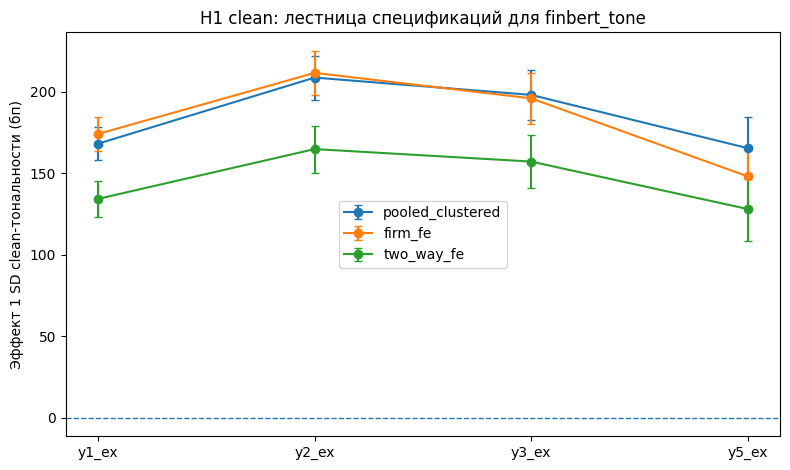

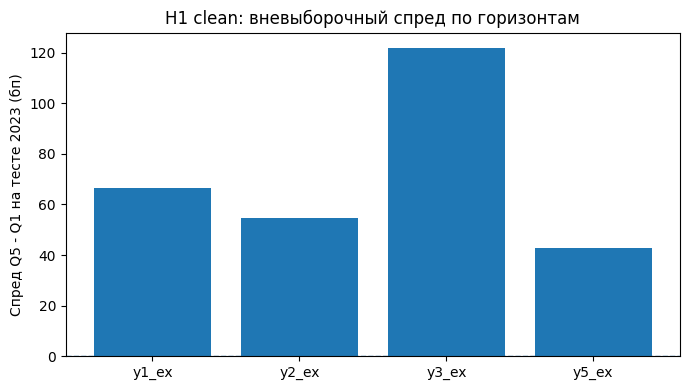

In [9]:
if not h1_clean.empty:
    tmp = h1_clean.copy()
    order_h = ["y1_ex", "y2_ex", "y3_ex", "y5_ex"]
    order_spec = ["pooled_clustered", "firm_fe", "two_way_fe"]

    plt.figure(figsize=(8, 4.8))
    for spec_name in order_spec:
        part = tmp[tmp["spec"] == spec_name].set_index("horizon").reindex(order_h)
        x = np.arange(len(order_h))
        y = part["effect_1sd_bps"].values
        err = 1.96 * part["se_1sd"].values * 10000
        plt.errorbar(x, y, yerr=err, marker="o", capsize=3, label=spec_name)

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(range(len(order_h)), order_h)
    plt.ylabel("Эффект 1 SD clean-тональности (бп)")
    plt.title(f"H1 clean: лестница спецификаций для {MAIN_MODEL}")
    plt.legend()
    plt.tight_layout()
    plt.show()

if not h1_clean_spreads.empty:
    tmp = h1_clean_spreads.sort_values("h_days").copy()
    x = np.arange(len(tmp))
    plt.figure(figsize=(7, 4))
    plt.bar(x, tmp["spread_q_last_minus_q1_bps"].values)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(x, tmp["horizon"])
    plt.ylabel("Спред Q5 - Q1 на тесте 2023 (бп)")
    plt.title("H1 clean: вневыборочный спред по горизонтам")
    plt.tight_layout()
    plt.show()

## 8. H2 на clean-подвыборке

Оценивается асимметрия негативной и позитивной компонент тональности на `clean`-сигнале

In [10]:
def run_h2_clean(df_in: pd.DataFrame) -> pd.DataFrame:
    y_col = "y1_ex"
    family = "clean"
    neg = f"{MAIN_MODEL}_{family}_neg_share"
    pos = f"{MAIN_MODEL}_{family}_pos_share"

    if neg not in df_in.columns or pos not in df_in.columns:
        return pd.DataFrame()

    sample = select_family_sample(df_in, family=family, model=MAIN_MODEL)
    train, _ = horizon_safe_split(sample, y_col, TEST_START)
    tr = clean_required(train, ["ticker", "date", y_col, neg, pos], [y_col, neg, pos])

    if APPLY_TRAIN_WINSOR and not tr.empty:
        tr, _, _ = apply_train_winsor_pair(tr, tr, y_col, p=WINSOR_P)

    model, used, kept = fit_clustered_model(
        tr,
        y=y_col,
        x_cols=[neg, pos],
        fe_cols=["ticker", "date"],
        cluster_cols=["ticker", "date"],
        add_const=False,
    )
    if model is None:
        return pd.DataFrame()

    st_neg = coef_stats(model, neg)
    st_pos = coef_stats(model, pos)
    contrast = linear_combo(model, {neg: 1.0, pos: -1.0})

    out = pd.DataFrame([{
        "model": MAIN_MODEL,
        "family": family,
        "beta_neg": st_neg["beta"],
        "se_neg": st_neg["se"],
        "t_neg": st_neg["t"],
        "beta_pos": st_pos["beta"],
        "se_pos": st_pos["se"],
        "t_pos": st_pos["t"],
        "contrast_neg_minus_pos": contrast["beta"],
        "contrast_p_two_sided": contrast["p_two"],
        "direction_ok": bool(
            np.isfinite(contrast["beta"]) and (contrast["beta"] < 0)
            and np.isfinite(st_neg["beta"]) and (st_neg["beta"] < 0)
            and np.isfinite(st_pos["beta"]) and (st_pos["beta"] > 0)
        ),
    }])
    return out

h2_clean = run_h2_clean(df)
display(h2_clean)
h2_clean.to_csv(os.path.join(ANALYSIS_DIR, "H2_clean_asymmetry.csv"), index=False)

,model,family,beta_neg,se_neg,t_neg,beta_pos,se_pos,t_pos,contrast_neg_minus_pos,contrast_p_two_sided,direction_ok
0,finbert_tone,clean,-0.022221,0.001753,-12.678282,0.019885,0.001562,12.728619,-0.042106,9.012293e-121,True


## 9. H3 на clean-подвыборке

Сравнивает несколько моделей на общем `clean`-пересечении наблюдений, если в данных доступны результаты более чем одной модели

In [11]:
def run_h3_clean(df_in: pd.DataFrame, model_list: List[str]) -> pd.DataFrame:
    if len(model_list) < 2:
        return pd.DataFrame()

    y_col = "y1_ex"
    score_cols = [f"{m}_clean_score_mean" for m in model_list if f"{m}_clean_score_mean" in df_in.columns]
    count_cols = [f"{m}_clean_news_count" for m in model_list if f"{m}_clean_news_count" in df_in.columns]
    if len(score_cols) < 2:
        return pd.DataFrame()


    work = df_in[["ticker", "date", y_col] + score_cols].copy()
    for m in model_list:
        cnt = f"{m}_clean_news_count"
        if cnt in df_in.columns:
            work[cnt] = pd.to_numeric(df_in[cnt], errors="coerce").fillna(0)


    keep_mask = np.ones(len(work), dtype=bool)
    for m in model_list:
        cnt = f"{m}_clean_news_count"
        if cnt in work.columns:
            keep_mask &= work[cnt].gt(0).values
    work = work.loc[keep_mask].copy()

    train, _ = horizon_safe_split(work, y_col, TEST_START)
    tr = clean_required(train, ["ticker", "date", y_col] + score_cols, [y_col] + score_cols)
    if tr.empty:
        return pd.DataFrame()

    if APPLY_TRAIN_WINSOR:
        tr, _, _ = apply_train_winsor_pair(tr, tr, y_col, p=WINSOR_P)

    rows = []
    for m in model_list:
        x_col = f"{m}_clean_score_mean"
        part = tr[["ticker", "date", y_col, x_col]].copy()
        part["sent_z"], mu, sd = standardize_on_train(part[x_col], part[x_col])
        part = part.dropna(subset=["sent_z"]).copy()

        model, used, kept = fit_clustered_model(
            part,
            y=y_col,
            x_cols=["sent_z"],
            fe_cols=["ticker", "date"],
            cluster_cols=["ticker", "date"],
            add_const=False,
        )
        if model is None:
            continue

        st = coef_stats(model, "sent_z")
        rows.append({
            "model": m,
            "beta_1sd": st["beta"],
            "se_1sd": st["se"],
            "t": st["t"],
            "p_two_sided": st["p_two"],
            "effect_1sd_bps": 10000 * st["beta"],
            "n_common_train": int(model.nobs),
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values("beta_1sd", ascending=False).reset_index(drop=True)
        out["rank_by_beta"] = np.arange(1, len(out) + 1)
    return out

h3_clean = run_h3_clean(df, AVAILABLE_CLEAN_MODELS)
display_or_note(h3_clean)
if not h3_clean.empty:
    h3_clean.to_csv(os.path.join(ANALYSIS_DIR, "H3_clean_model_comparison.csv"), index=False)

## 10. H4 на clean-подвыборке

Проверяется, усиливается ли эффект тональности при росте числа новостей в `clean`-сигнале

In [12]:
def run_h4_clean(df_in: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    y_col = "y1_ex"
    family = "clean"
    x_col = f"{MAIN_MODEL}_{family}_score_mean"
    n_col = f"{MAIN_MODEL}_{family}_news_count"

    sample = select_family_sample(df_in, family=family, model=MAIN_MODEL)
    train, _ = horizon_safe_split(sample, y_col, TEST_START)
    tr = clean_required(train, ["ticker", "date", y_col, x_col, n_col], [y_col, x_col, n_col])
    if tr.empty:
        return pd.DataFrame(), pd.DataFrame()

    if APPLY_TRAIN_WINSOR:
        tr, _, _ = apply_train_winsor_pair(tr, tr, y_col, p=WINSOR_P)

    tr["sent_z"], mu, sd = standardize_on_train(tr[x_col], tr[x_col])
    tr = tr.dropna(subset=["sent_z"]).copy()
    tr["news_n"] = pd.to_numeric(tr[n_col], errors="coerce")
    tr["log_news"] = np.log1p(tr["news_n"])
    tr = tr.dropna(subset=["log_news"]).copy()

    tr["news_bin"] = pd.cut(
        tr["news_n"].astype(float),
        bins=[0, 1, 3, np.inf],
        labels=["1", "2-3", "4+"],
        right=True,
        include_lowest=False,
    )

    rows = []
    for b in ["1", "2-3", "4+"]:
        part = tr[tr["news_bin"] == b].copy()
        if part.empty:
            continue
        model, used, kept = fit_clustered_model(
            part,
            y=y_col,
            x_cols=["sent_z"],
            fe_cols=["ticker", "date"],
            cluster_cols=["ticker", "date"],
            add_const=False,
        )
        if model is None:
            continue
        st = coef_stats(model, "sent_z")
        rows.append({
            "news_bin": b,
            "beta_1sd": st["beta"],
            "se_1sd": st["se"],
            "t": st["t"],
            "effect_1sd_bps": 10000 * st["beta"],
            "n_train": int(model.nobs),
        })
    bins_out = pd.DataFrame(rows)

    tr["sent_x_log_news"] = tr["sent_z"] * tr["log_news"]
    model_i, used_i, kept_i = fit_clustered_model(
        tr,
        y=y_col,
        x_cols=["sent_z", "log_news", "sent_x_log_news"],
        fe_cols=["ticker", "date"],
        cluster_cols=["ticker", "date"],
        add_const=False,
    )
    if model_i is None:
        return bins_out, pd.DataFrame()

    inter = coef_stats(model_i, "sent_x_log_news")
    inter_out = pd.DataFrame([{
        "beta_interaction": inter["beta"],
        "se_interaction": inter["se"],
        "t_interaction": inter["t"],
        "p_two_sided": inter["p_two"],
        "effect_bps": 10000 * inter["beta"],
        "n_train": int(model_i.nobs),
    }])
    return bins_out, inter_out

h4_bins_clean, h4_inter_clean = run_h4_clean(df)
display(h4_bins_clean)
display(h4_inter_clean)

h4_bins_clean.to_csv(os.path.join(ANALYSIS_DIR, "H4_clean_bins.csv"), index=False)
h4_inter_clean.to_csv(os.path.join(ANALYSIS_DIR, "H4_clean_interaction.csv"), index=False)

/var/folders/40/q550qlmj2939zzyhq2_61n7c0000gn/T/ipykernel_63686/1961983055.py:128: RuntimeWarning: within_transform остановился на max_iter=500 с последним отклонением = 7.832e-06; принимается как численно сошедшийся при relaxed_tol = 1.000e-05.
  warnings.warn(


,news_bin,beta_1sd,se_1sd,t,effect_1sd_bps,n_train
0,1,0.011857,0.000560,21.162471,118.565587,8849
1,2-3,0.015978,0.002137,7.478308,159.783318,1855
2,4+,-0.050560,0.010084,-5.014065,-505.601530,325


,beta_interaction,se_interaction,t_interaction,p_two_sided,effect_bps,n_train
0,0.021187,0.002848,7.440494,1.077703e-13,211.872666,11029


## 11. H5 на clean-подвыборке

Оценивается секторная неоднородность эффекта на `clean`-выборке

In [13]:
def safe_name(x: str) -> str:
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(x)).strip("_").lower()

def run_h5_clean(df_in: pd.DataFrame, top_sectors: int = 10) -> pd.DataFrame:
    y_col = "y1_ex"
    family = "clean"
    x_col = f"{MAIN_MODEL}_{family}_score_mean"
    if "sector" not in df_in.columns:
        return pd.DataFrame()

    sample = select_family_sample(df_in, family=family, model=MAIN_MODEL)
    train, _ = horizon_safe_split(sample, y_col, TEST_START)
    tr = clean_required(train, ["ticker", "date", "sector", y_col, x_col], [y_col, x_col])
    if tr.empty:
        return pd.DataFrame()

    if APPLY_TRAIN_WINSOR:
        tr, _, _ = apply_train_winsor_pair(tr, tr, y_col, p=WINSOR_P)

    tr["sector"] = tr["sector"].astype(str).str.strip()
    tr = tr[(tr["sector"] != "") & (tr["sector"].str.lower() != "nan")].copy()
    if tr.empty:
        return pd.DataFrame()

    tr["sent_z"], mu, sd = standardize_on_train(tr[x_col], tr[x_col])
    tr = tr.dropna(subset=["sent_z"]).copy()

    top = tr["sector"].value_counts().head(top_sectors).index.tolist()
    tr = tr[tr["sector"].isin(top)].copy()
    if tr.empty:
        return pd.DataFrame()

    baseline = top[0]
    int_cols = []
    sector_map = {}
    counts = tr["sector"].value_counts().to_dict()

    for s in top[1:]:
        name = f"sent_x_sec_{safe_name(s)}"
        tr[name] = tr["sent_z"] * (tr["sector"] == s).astype(float)
        int_cols.append(name)
        sector_map[s] = name

    model, used, kept = fit_clustered_model(
        tr,
        y=y_col,
        x_cols=["sent_z"] + int_cols,
        fe_cols=["ticker", "date"],
        cluster_cols=["ticker", "date"],
        add_const=False,
    )
    if model is None:
        return pd.DataFrame()

    rows = []
    base = linear_combo(model, {"sent_z": 1.0})
    rows.append({
        "sector": baseline,
        "beta_1sd": base["beta"],
        "se_1sd": base["se"],
        "t": base["t"],
        "n_sector_obs": int(counts.get(baseline, 0)),
        "is_baseline": True,
    })

    for s in top[1:]:
        combo = linear_combo(model, {"sent_z": 1.0, sector_map[s]: 1.0})
        rows.append({
            "sector": s,
            "beta_1sd": combo["beta"],
            "se_1sd": combo["se"],
            "t": combo["t"],
            "n_sector_obs": int(counts.get(s, 0)),
            "is_baseline": False,
        })

    stat, p_joint = wald_joint_zero(model, int_cols)
    out = pd.DataFrame(rows)
    out["wald_stat_interactions"] = stat
    out["p_joint_interactions"] = p_joint
    out["effect_1sd_bps"] = 10000 * out["beta_1sd"]
    return out.sort_values("beta_1sd", ascending=False).reset_index(drop=True)

h5_clean = run_h5_clean(df)
display_or_note(h5_clean)
if not h5_clean.empty:
    h5_clean.to_csv(os.path.join(ANALYSIS_DIR, "H5_clean_sector_heterogeneity.csv"), index=False)

## 12. H6 на clean-подвыборке

Пересчитывается затухание эффекта по горизонтам и формируются таблицы для сравнения дневного вклада сигнала

In [14]:
def run_h6_clean(df_in: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    family = "clean"
    x_col = f"{MAIN_MODEL}_{family}_score_mean"
    horizon_grid = [("y1_ex", 1), ("y2_ex", 2), ("y3_ex", 3), ("y5_ex", 5)]

    sample = select_family_sample(df_in, family=family, model=MAIN_MODEL)
    common_train, _ = horizon_safe_split(sample, "y5_ex", TEST_START)
    keep = ["ticker", "date", x_col, "y1_ex", "y2_ex", "y3_ex", "y5_ex"]
    tr = clean_required(common_train, keep, [x_col, "y1_ex", "y2_ex", "y3_ex", "y5_ex"])
    if tr.empty:
        return pd.DataFrame(), pd.DataFrame()

    tr["sent_z"], mu, sd = standardize_on_train(tr[x_col], tr[x_col])
    tr = tr.dropna(subset=["sent_z"]).copy()

    curve_rows = []
    long_parts = []

    for y_col, h in horizon_grid:
        work = tr[["ticker", "date", "sent_z", y_col]].copy()

        if APPLY_TRAIN_WINSOR:
            lo, hi = winsor_bounds(work[y_col], p=WINSOR_P)
            work[y_col] = apply_bounds(work[y_col], lo, hi)

        model, used, kept = fit_clustered_model(
            work,
            y=y_col,
            x_cols=["sent_z"],
            fe_cols=["ticker", "date"],
            cluster_cols=["ticker", "date"],
            add_const=False,
        )
        if model is None:
            continue

        st = coef_stats(model, "sent_z")
        curve_rows.append({
            "horizon": y_col,
            "h_days": h,
            "beta_cum_1sd": st["beta"],
            "se_cum_1sd": st["se"],
            "beta_per_day_1sd": st["beta"] / h if np.isfinite(st["beta"]) else np.nan,
            "se_per_day_1sd": st["se"] / h if np.isfinite(st["se"]) else np.nan,
            "t": st["t"],
            "p_two_sided": st["p_two"],
        })

        part = work.rename(columns={y_col: "y_raw"}).copy()
        part["h_days"] = h
        part["y_avg"] = part["y_raw"] / h
        long_parts.append(part[["ticker", "date", "sent_z", "h_days", "y_raw", "y_avg"]])

    curve = pd.DataFrame(curve_rows).sort_values("h_days").reset_index(drop=True)
    if curve.empty:
        return curve, pd.DataFrame()

    long = pd.concat(long_parts, ignore_index=True)
    long["obs_id"] = pd.factorize(long["ticker"].astype(str) + "|" + long["date"].astype(str))[0]

    dummies = pd.get_dummies(
        pd.Categorical(long["h_days"].astype(str), categories=["1", "2", "3", "5"], ordered=True),
        prefix="h",
        drop_first=True,
        dtype=float,
    )
    for c in dummies.columns:
        long[c] = dummies[c].values.astype(float)

    int_cols = []
    for h in [2, 3, 5]:
        dummy_col = f"h_{h}"
        int_col = f"sent_x_h_{h}"
        long[int_col] = long["sent_z"] * long[dummy_col]
        int_cols.append(int_col)

    model_i, used_i, kept_i = fit_clustered_model(
        long,
        y="y_avg",
        x_cols=list(dummies.columns) + int_cols,
        fe_cols=["obs_id"],
        cluster_cols=["obs_id", "date"],
        add_const=False,
    )
    if model_i is None:
        return curve, pd.DataFrame()

    delta_h5 = linear_combo(model_i, {"sent_x_h_5": 1.0})
    stat, p_joint = wald_joint_zero(model_i, int_cols)

    inter = pd.DataFrame([{
        "delta_h5_vs_h1": delta_h5["beta"],
        "delta_h5_vs_h1_p_two_sided": delta_h5["p_two"],
        "wald_stat_interactions": stat,
        "p_joint_interactions": p_joint,
    }])
    return curve, inter

h6_curve_clean, h6_inter_clean = run_h6_clean(df)
display(h6_curve_clean)
display(h6_inter_clean)

h6_curve_clean.to_csv(os.path.join(ANALYSIS_DIR, "H6_clean_curve.csv"), index=False)
h6_inter_clean.to_csv(os.path.join(ANALYSIS_DIR, "H6_clean_interactions.csv"), index=False)

,horizon,h_days,beta_cum_1sd,se_cum_1sd,beta_per_day_1sd,se_per_day_1sd,t,p_two_sided
0,y1_ex,1,0.013425,0.000565,0.013425,0.000565,23.746809,1.296108e-121
1,y2_ex,2,0.016474,0.000736,0.008237,0.000368,22.370861,1.914963e-108
2,y3_ex,3,0.015709,0.000835,0.005236,0.000278,18.824192,7.889415e-78
3,y5_ex,5,0.012803,0.000987,0.002561,0.000197,12.972097,3.350665e-38


,delta_h5_vs_h1,delta_h5_vs_h1_p_two_sided,wald_stat_interactions,p_joint_interactions
0,-0.013612,0.0,2701.952823,0.0


### График затухания

График дневного эффекта по горизонтам для `clean`-сигнала

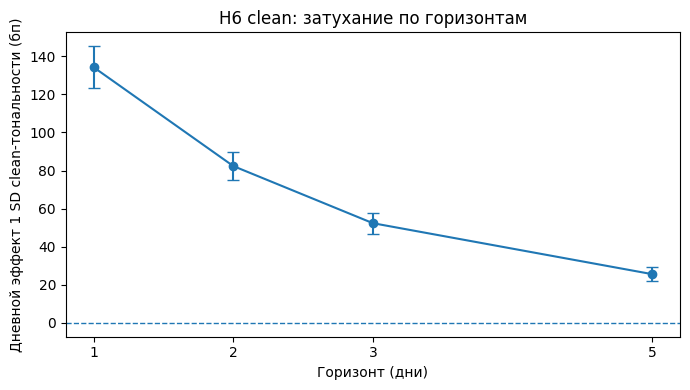

In [15]:
if not h6_curve_clean.empty:
    tmp = h6_curve_clean.sort_values("h_days").copy()
    x = tmp["h_days"].values.astype(float)
    y = tmp["beta_per_day_1sd"].values * 10000
    err = 1.96 * tmp["se_per_day_1sd"].values * 10000

    plt.figure(figsize=(7, 4))
    plt.plot(x, y, marker="o")
    plt.errorbar(x, y, yerr=err, fmt="none", capsize=4)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(x, [str(int(v)) for v in x])
    plt.xlabel("Горизонт (дни)")
    plt.ylabel("Дневной эффект 1 SD clean-тональности (бп)")
    plt.title("H6 clean: затухание по горизонтам")
    plt.tight_layout()
    plt.show()

## 13. H7 на clean-подвыборке

Проверяется устойчивость эффекта по годам на `clean`-выборке

In [16]:
def run_h7_clean(df_in: pd.DataFrame) -> pd.DataFrame:
    y_col = "y1_ex"
    family = "clean"
    x_col = f"{MAIN_MODEL}_{family}_score_mean"
    sample = select_family_sample(df_in, family=family, model=MAIN_MODEL)
    d = clean_required(sample, ["ticker", "date", y_col, x_col], [y_col, x_col])
    if d.empty:
        return pd.DataFrame()

    train_for_scale = d[d["date"] < TEST_START].copy()
    if APPLY_TRAIN_WINSOR and not train_for_scale.empty:
        lo, hi = winsor_bounds(train_for_scale[y_col], p=WINSOR_P)
        d[y_col] = apply_bounds(d[y_col], lo, hi)

    d["sent_z"], mu, sd = standardize_on_train(train_for_scale[x_col], d[x_col])
    d = d.dropna(subset=["sent_z"]).copy()
    d["year"] = d["date"].dt.year.astype(int)

    rows = []
    for yr, g in d.groupby("year", sort=True):
        model, used, kept = fit_clustered_model(
            g,
            y=y_col,
            x_cols=["sent_z"],
            fe_cols=["ticker", "date"],
            cluster_cols=["ticker", "date"],
            add_const=False,
        )
        if model is None:
            continue
        st = coef_stats(model, "sent_z")
        rows.append({
            "year": int(yr),
            "beta_1sd": st["beta"],
            "se_1sd": st["se"],
            "t": st["t"],
            "p_two_sided": st["p_two"],
            "effect_1sd_bps": 10000 * st["beta"],
            "n_year": int(model.nobs),
        })

    out = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
    if out.empty:
        return out

    year_order = sorted(d["year"].unique().tolist())
    baseline = int(year_order[0])

    int_cols = []
    for yr in year_order[1:]:
        c = f"sent_x_year_{yr}"
        d[c] = d["sent_z"] * (d["year"] == yr).astype(float)
        int_cols.append(c)

    model_i, used_i, kept_i = fit_clustered_model(
        d,
        y=y_col,
        x_cols=["sent_z"] + int_cols,
        fe_cols=["ticker", "date"],
        cluster_cols=["ticker", "date"],
        add_const=False,
    )
    if model_i is not None:
        stat, p_joint = wald_joint_zero(model_i, int_cols)
        out["baseline_year"] = baseline
        out["wald_stat_interactions"] = stat
        out["p_joint_year_interactions"] = p_joint

    return out

h7_clean = run_h7_clean(df)
display(h7_clean)
if not h7_clean.empty:
    h7_clean.to_csv(os.path.join(ANALYSIS_DIR, "H7_clean_year_stability.csv"), index=False)

,year,beta_1sd,se_1sd,t,p_two_sided,effect_1sd_bps,n_year,baseline_year,wald_stat_interactions,p_joint_year_interactions
0,2019,0.009239,0.001840,5.020773,6.168491e-07,92.392475,930,2019,11.793338,0.002749
1,2020,0.013809,0.000596,23.170437,9.144693e-116,138.091281,10099,2019,11.793338,0.002749


## 14. Итоговые таблицы

In [17]:
def build_final_tables():
    confirm_rows = []
    expl_rows = []

    main_row = h1_clean[(h1_clean["spec"] == "two_way_fe") & (h1_clean["horizon"] == "y1_ex")].copy()
    if len(main_row):
        r = main_row.iloc[0]
        confirm_rows.append({
            "test_id": "H1_clean_main",
            "label": "Clean-тональность предсказывает избыточную доходность следующего дня (TWFE, train)",
            "estimate_bps": r["effect_1sd_bps"],
            "p_raw": r["p_two_sided"],
            "direction_ok": bool(np.isfinite(r["beta_1sd"]) and r["beta_1sd"] > 0),
        })

    if len(h2_clean):
        r = h2_clean.iloc[0]
        confirm_rows.append({
            "test_id": "H2_clean_asymmetry",
            "label": "Негативная clean-компонента сильнее позитивной",
            "estimate_bps": 10000 * r["contrast_neg_minus_pos"],
            "p_raw": r["contrast_p_two_sided"],
            "direction_ok": bool(r["direction_ok"]),
        })

    if len(h4_inter_clean):
        r = h4_inter_clean.iloc[0]
        confirm_rows.append({
            "test_id": "H4_clean_volume_interaction",
            "label": "Clean-сигнал усиливается при росте числа новостей с корректным временем",
            "estimate_bps": r["effect_bps"],
            "p_raw": r["p_two_sided"],
            "direction_ok": bool(np.isfinite(r["beta_interaction"]) and r["beta_interaction"] > 0),
        })

    if len(h6_inter_clean):
        r = h6_inter_clean.iloc[0]
        confirm_rows.append({
            "test_id": "H6_clean_decay",
            "label": "Дневной clean-эффект на h=5 ниже, чем на h=1",
            "estimate_bps": 10000 * r["delta_h5_vs_h1"],
            "p_raw": r["delta_h5_vs_h1_p_two_sided"],
            "direction_ok": bool(np.isfinite(r["delta_h5_vs_h1"]) and r["delta_h5_vs_h1"] < 0),
        })

    confirm = pd.DataFrame(confirm_rows)
    if not confirm.empty:
        confirm["q_global"] = bh_fdr(confirm["p_raw"].values)
        confirm["supported_q_0_05"] = confirm["direction_ok"] & (confirm["q_global"] < ALPHA)

    if len(family_cmp):
        for _, r in family_cmp.iterrows():
            expl_rows.append({
                "section": "timing_family_cmp",
                "label": f"Семейство {r['family']}: основной эффект и placebo",
                "estimate_bps": r["main_beta_bps"],
                "placebo_bps": r["placebo_beta_bps"],
                "p_raw": r["main_p_two_sided"],
                "extra": r["abs_placebo_over_abs_main"],
            })

    if len(h1_clean_spreads):
        for _, r in h1_clean_spreads.iterrows():
            expl_rows.append({
                "section": "clean_test_sort",
                "label": f"Clean-спред 2023 {r['horizon']}: Q{TEST_SORT_Q} - Q1",
                "estimate_bps": r["spread_q_last_minus_q1_bps"],
                "placebo_bps": np.nan,
                "p_raw": r["p_two_sided"],
                "extra": np.nan,
            })

    if len(h3_clean):
        for _, r in h3_clean.iterrows():
            expl_rows.append({
                "section": "H3_clean",
                "label": f"Сравнение clean-моделей: {r['model']}",
                "estimate_bps": r["effect_1sd_bps"],
                "placebo_bps": np.nan,
                "p_raw": r["p_two_sided"],
                "extra": r["rank_by_beta"],
            })

    if len(h5_clean):
        expl_rows.append({
            "section": "H5_clean",
            "label": "Секторная неоднородность на clean-выборке (совместный тест)",
            "estimate_bps": np.nan,
            "placebo_bps": np.nan,
            "p_raw": float(h5_clean["p_joint_interactions"].dropna().iloc[0]) if h5_clean["p_joint_interactions"].notna().any() else np.nan,
            "extra": np.nan,
        })

    if len(h7_clean):
        expl_rows.append({
            "section": "H7_clean",
            "label": "Нестабильность по годам на clean-выборке (совместный тест)",
            "estimate_bps": np.nan,
            "placebo_bps": np.nan,
            "p_raw": float(h7_clean["p_joint_year_interactions"].dropna().iloc[0]) if "p_joint_year_interactions" in h7_clean.columns and h7_clean["p_joint_year_interactions"].notna().any() else np.nan,
            "extra": np.nan,
        })

    exploratory = pd.DataFrame(expl_rows)
    if not exploratory.empty:
        exploratory["q_within_table"] = bh_fdr(exploratory["p_raw"].values)

    return confirm, exploratory

confirmatory_table, exploratory_table = build_final_tables()
display(confirmatory_table)
display(exploratory_table)

confirmatory_table.to_csv(os.path.join(ANALYSIS_DIR, "confirmatory_clean_table.csv"), index=False)
exploratory_table.to_csv(os.path.join(ANALYSIS_DIR, "exploratory_timing_table.csv"), index=False)

,test_id,label,estimate_bps,p_raw,direction_ok,q_global,supported_q_0_05
0,H1_clean_main,Clean-тональность предсказывает избыточную дох...,134.253017,1.296108e-121,True,2.592217e-121,True
1,H2_clean_asymmetry,Негативная clean-компонента сильнее позитивной,-421.062916,9.012293e-121,True,1.201639e-120,True
2,H4_clean_volume_interaction,Clean-сигнал усиливается при росте числа новос...,211.872666,1.077703e-13,True,1.077703e-13,True
3,H6_clean_decay,"Дневной clean-эффект на h=5 ниже, чем на h=1",-136.119572,0.000000e+00,True,0.000000e+00,True


,section,label,estimate_bps,placebo_bps,p_raw,extra,q_within_table
0,timing_family_cmp,Семейство legacy: основной эффект и placebo,5.286732,12.326464,1.233667e-30,2.331585,2.467335e-30
1,timing_family_cmp,Семейство clean: основной эффект и placebo,134.253017,-7.520495,1.296108e-121,0.056017,1.036887e-120
2,timing_family_cmp,Семейство after_close: основной эффект и placebo,138.949834,42.829502,9.587763e-18,0.308237,1.278368e-17
3,timing_family_cmp,Семейство pre_open: основной эффект и placebo,120.630794,-12.136456,3.614210e-81,0.100608,9.637893e-81
4,timing_family_cmp,Семейство non_trading: основной эффект и placebo,105.960250,-40.609444,6.962282e-05,0.383252,7.956894e-05
5,timing_family_cmp,Семейство intraday: основной эффект и placebo,616.833333,-152.672602,1.943673e-106,0.247510,7.774694e-106
6,timing_family_cmp,Семейство unknown: основной эффект и placebo,4.705270,12.282112,5.884248e-25,2.610289,9.414796e-25
7,clean_test_sort,Clean-спред 2023 y1_ex: Q5 - Q1,66.636245,NaN,NaN,NaN,NaN
8,clean_test_sort,Clean-спред 2023 y2_ex: Q5 - Q1,54.793319,NaN,NaN,NaN,NaN
9,clean_test_sort,Clean-спред 2023 y3_ex: Q5 - Q1,121.855277,NaN,NaN,NaN,NaN


## 15. Аудит временных меток во всём дедуплицированном корпусе

Считается доля статей с точным временем публикации во всём дедуплицированном новостном файле

In [18]:
import pandas as pd

counts = {"total": 0, "has_time": 0}
for chunk in pd.read_csv("outputs_01/news_deduped_2019_2023.csv",
                         usecols=["Date"],
                         chunksize=200_000,
                         low_memory=False):
    parsed = pd.to_datetime(chunk["Date"], errors="coerce", utc=True)
    valid = parsed.dropna()
    counts["total"] += len(valid)
    counts["has_time"] += (valid.dt.time != pd.Timestamp("00:00:00").time()).sum()

pct = 100 * counts["has_time"] / counts["total"]
print("Дедуплицированный файл:")
print(f"  Всего: {counts['total']:,}")
print(f"  С точным временем: {counts['has_time']:,} ({pct:.1f}%)")
print(f"  Без времени:        {counts['total'] - counts['has_time']:,} ({100-pct:.1f}%)")

Дедуплицированный файл:
  Всего: 15,537,384
  С точным временем: 8,616,482 (55.5%)
  Без времени:        6,920,902 (44.5%)


## 16. Аудит временных меток для итоговой выборки тикеров

Считается доля статей с точным временем публикации только для тех тикеров, которые вошли в финальную выборку исследования

In [19]:
import pandas as pd

counts = {"total": 0, "in_tickers": 0, "in_tickers_has_time": 0}

tickers = set(pd.read_csv("outputs_01/selected_equities_only_2019_2023.csv")["ticker"].astype(str).str.strip())

for chunk in pd.read_csv("outputs_01/news_deduped_2019_2023.csv",
                         usecols=["Date", "Stock_symbol"],
                         chunksize=200_000, low_memory=False):
    chunk["ticker"] = chunk["Stock_symbol"].astype(str).str.strip()
    chunk["ts"] = pd.to_datetime(chunk["Date"], errors="coerce", utc=True)
    valid = chunk.dropna(subset=["ts"])
    counts["total"] += len(valid)

    in_tk = valid[valid["ticker"].isin(tickers)]
    counts["in_tickers"] += len(in_tk)
    counts["in_tickers_has_time"] += (in_tk["ts"].dt.time != pd.Timestamp("00:00:00").time()).sum()

pct = 100 * counts["in_tickers_has_time"] / counts["in_tickers"] if counts["in_tickers"] else 0
print(f"Всего строк: {counts['total']:,}")
print(f"В отобранных тикерах: {counts['in_tickers']:,}")
print(f"  С точным временем: {counts['in_tickers_has_time']:,} ({pct:.1f}%)")
print(f"  Без времени:        {counts['in_tickers'] - counts['in_tickers_has_time']:,} ({100-pct:.1f}%)")

Всего строк: 15,537,384
В отобранных тикерах: 2,714,932
  С точным временем: 22,709 (0.8%)
  Без времени:        2,692,223 (99.2%)
